In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing
import math
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from xgboost import XGBRegressor
import optuna

# Ignore warnings ;)
import warnings
warnings.simplefilter("ignore")

import pickle

# set seed for reproductibility
np.random.seed(0)


In [5]:
train = pd.read_csv('D:/mythings/train.csv')
test = pd.read_csv('D:/mythings/test.csv')
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
train.info()

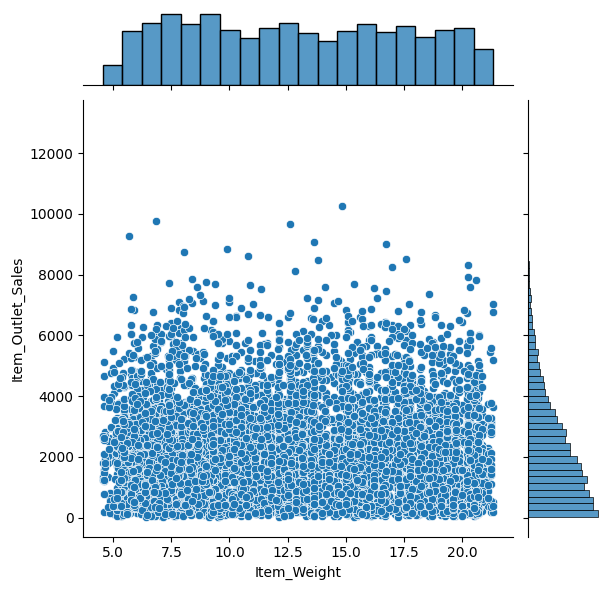

In [7]:
train.isnull().sum().sort_values(ascending=False)
sns.jointplot(data = train, x = 'Item_Weight', y='Item_Outlet_Sales')

In [6]:
train['Outlet_Establishment_Year'].value_counts()
train['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [8]:
test.head()
test.shape
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [9]:
numeric_cols = train.select_dtypes(include=['float64','int64']).columns.to_list()
numeric_cols
#DataFrame.describe().T will transpose 
# ['count','mean','std','min','max','25%','50%','75%']
# from indexes to columns
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


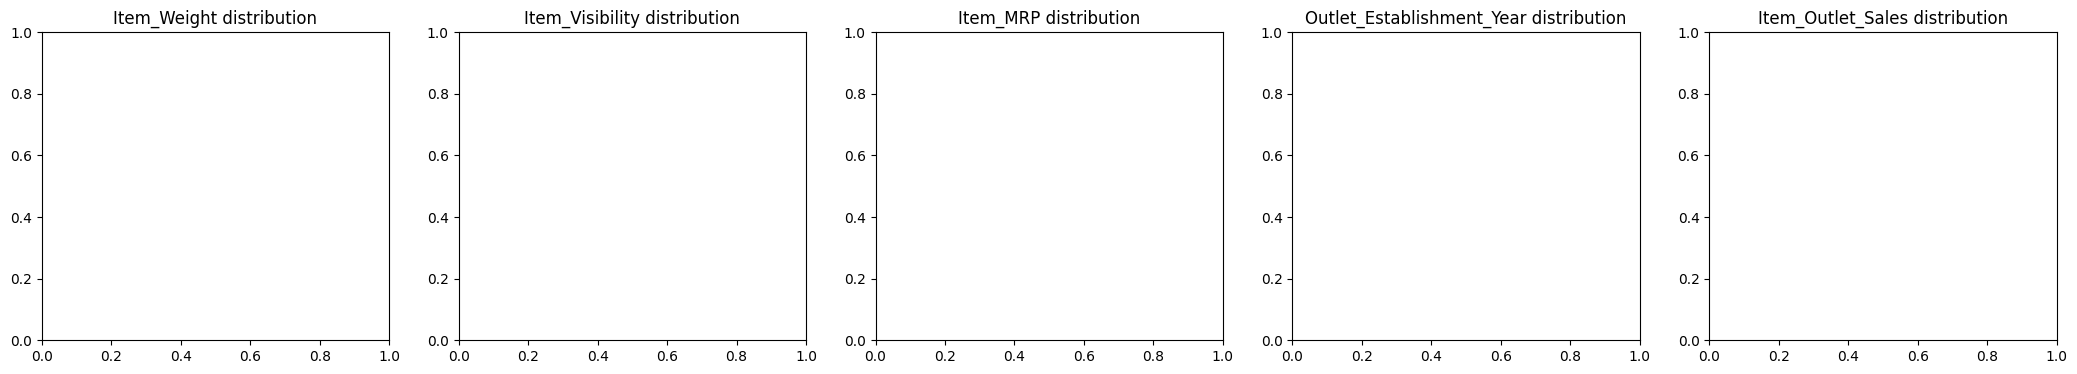

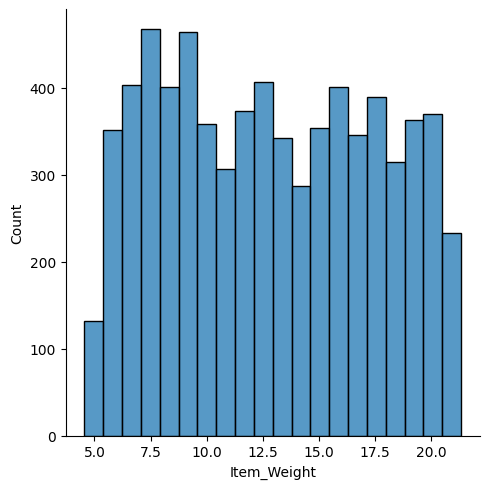

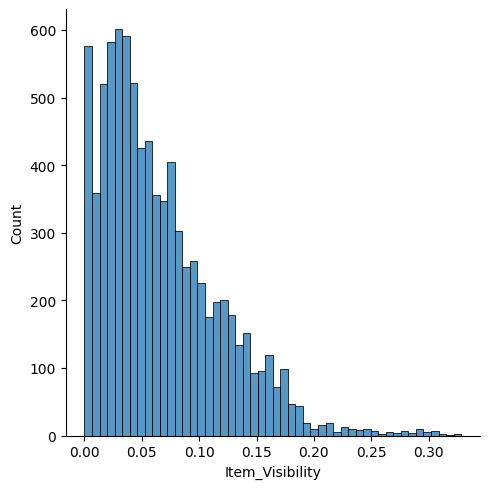

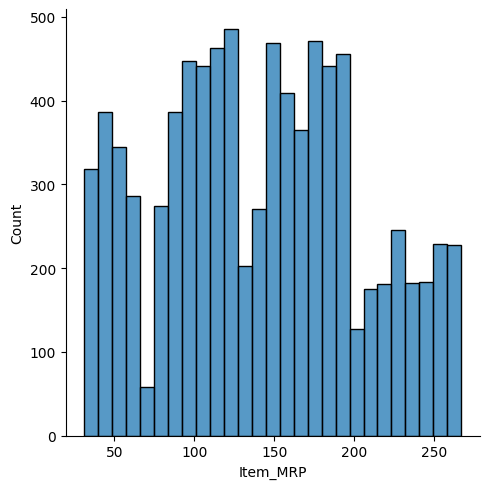

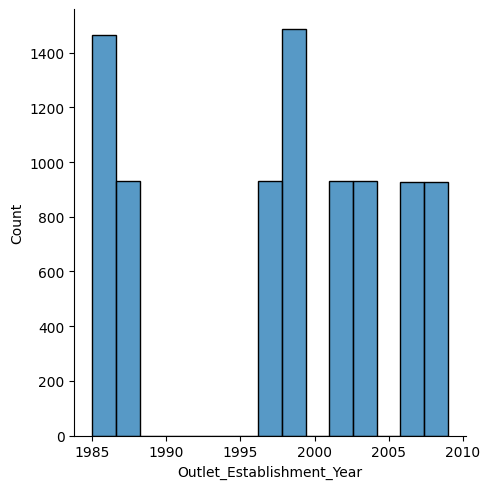

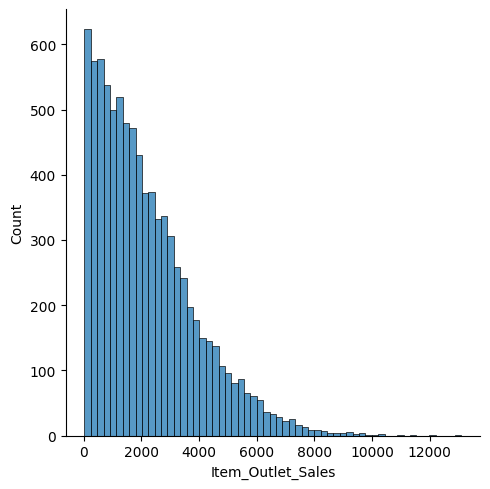

In [10]:
_, ax = plt.subplots(nrows=1, ncols=5, figsize=(26, 4))
for index, col in enumerate(numeric_cols):
    sns.displot(data = train[col], kde = False, ax = ax[index])
    ax[index].set_title(f'{col} distribution')

In [ ]:
_, ax = plt.subplots(nrows = 1, ncols = 5, figsize = (26,4))
for index, col in enumerate(numeric_cols):
    sns.kdeplot(data = train, x = col, ax = ax[index])
    ax[index].set_title(f'{col} distribution in Train')

In [ ]:
#Comparing with Train data, there is no differnece in the distribution between Train and Test
_, ax = plt.subplots(nrows = 1 , ncols = 4, figsize = (26,4))
for index, col in enumerate(['Item_Weight','Item_Visibility','Item_MRP','Outlet_Establishment_Year']):
    sns.displot(data = test[col], kde = True, ax = ax[index])
    ax[index].set_title(f'{col} distribution in Test')

In [ ]:
# identify which cols have outliers.
# it is clearly to see that outliers are in Item_Visibility and Item_Outlet_Sales
_, ax = plt.subplots(nrows = 1, ncols = 5, figsize=(26,4))
for index, col in enumerate(numeric_cols):
    sns.boxplot(data = train, y = col, ax = ax[index])
    ax[index].set_title(f'{col} distribution')

In [ ]:
_, ax = plt.subplots(nrows = 1, ncols = 5 , figsize = ( 26,8))
for index, col in enumerate(numeric_cols):
    sns.violinplot(data = train, y = col, ax = ax[index], inner = 'quartile')
    ax[index].set_title(f'{col} distribution')

In [11]:
categorical_cols = train.select_dtypes(include='object').columns.to_list()
categorical_to_display = [
    'Item_Fat_Content','Item_Type','Outlet_Size','Outlet_Location_Type','Outlet_Type'
    ]
for col in categorical_to_display:
    print(f'Number of values in the {col} column is :\n{train[col].value_counts()}')
    print('--'*30)

Number of values in the Item_Fat_Content column is :
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
------------------------------------------------------------
Number of values in the Item_Type column is :
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
------------------------------------------------------------
Number of values in the Outlet_Size column is :
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64
---------

' Item_Fat_Content has some entry errors (Low Fat, LF, low fat should be considered as 1)\nSame problem with variable Regular and reg\n    Item_Type: should categorise the variables having same attribution (soft drink\nand hard drink is about drink; seafood, snack foods, starchy foods, frozen foods as Food)\n    Encode Outlet_Location_Type (from Tier 1 -> 1)'

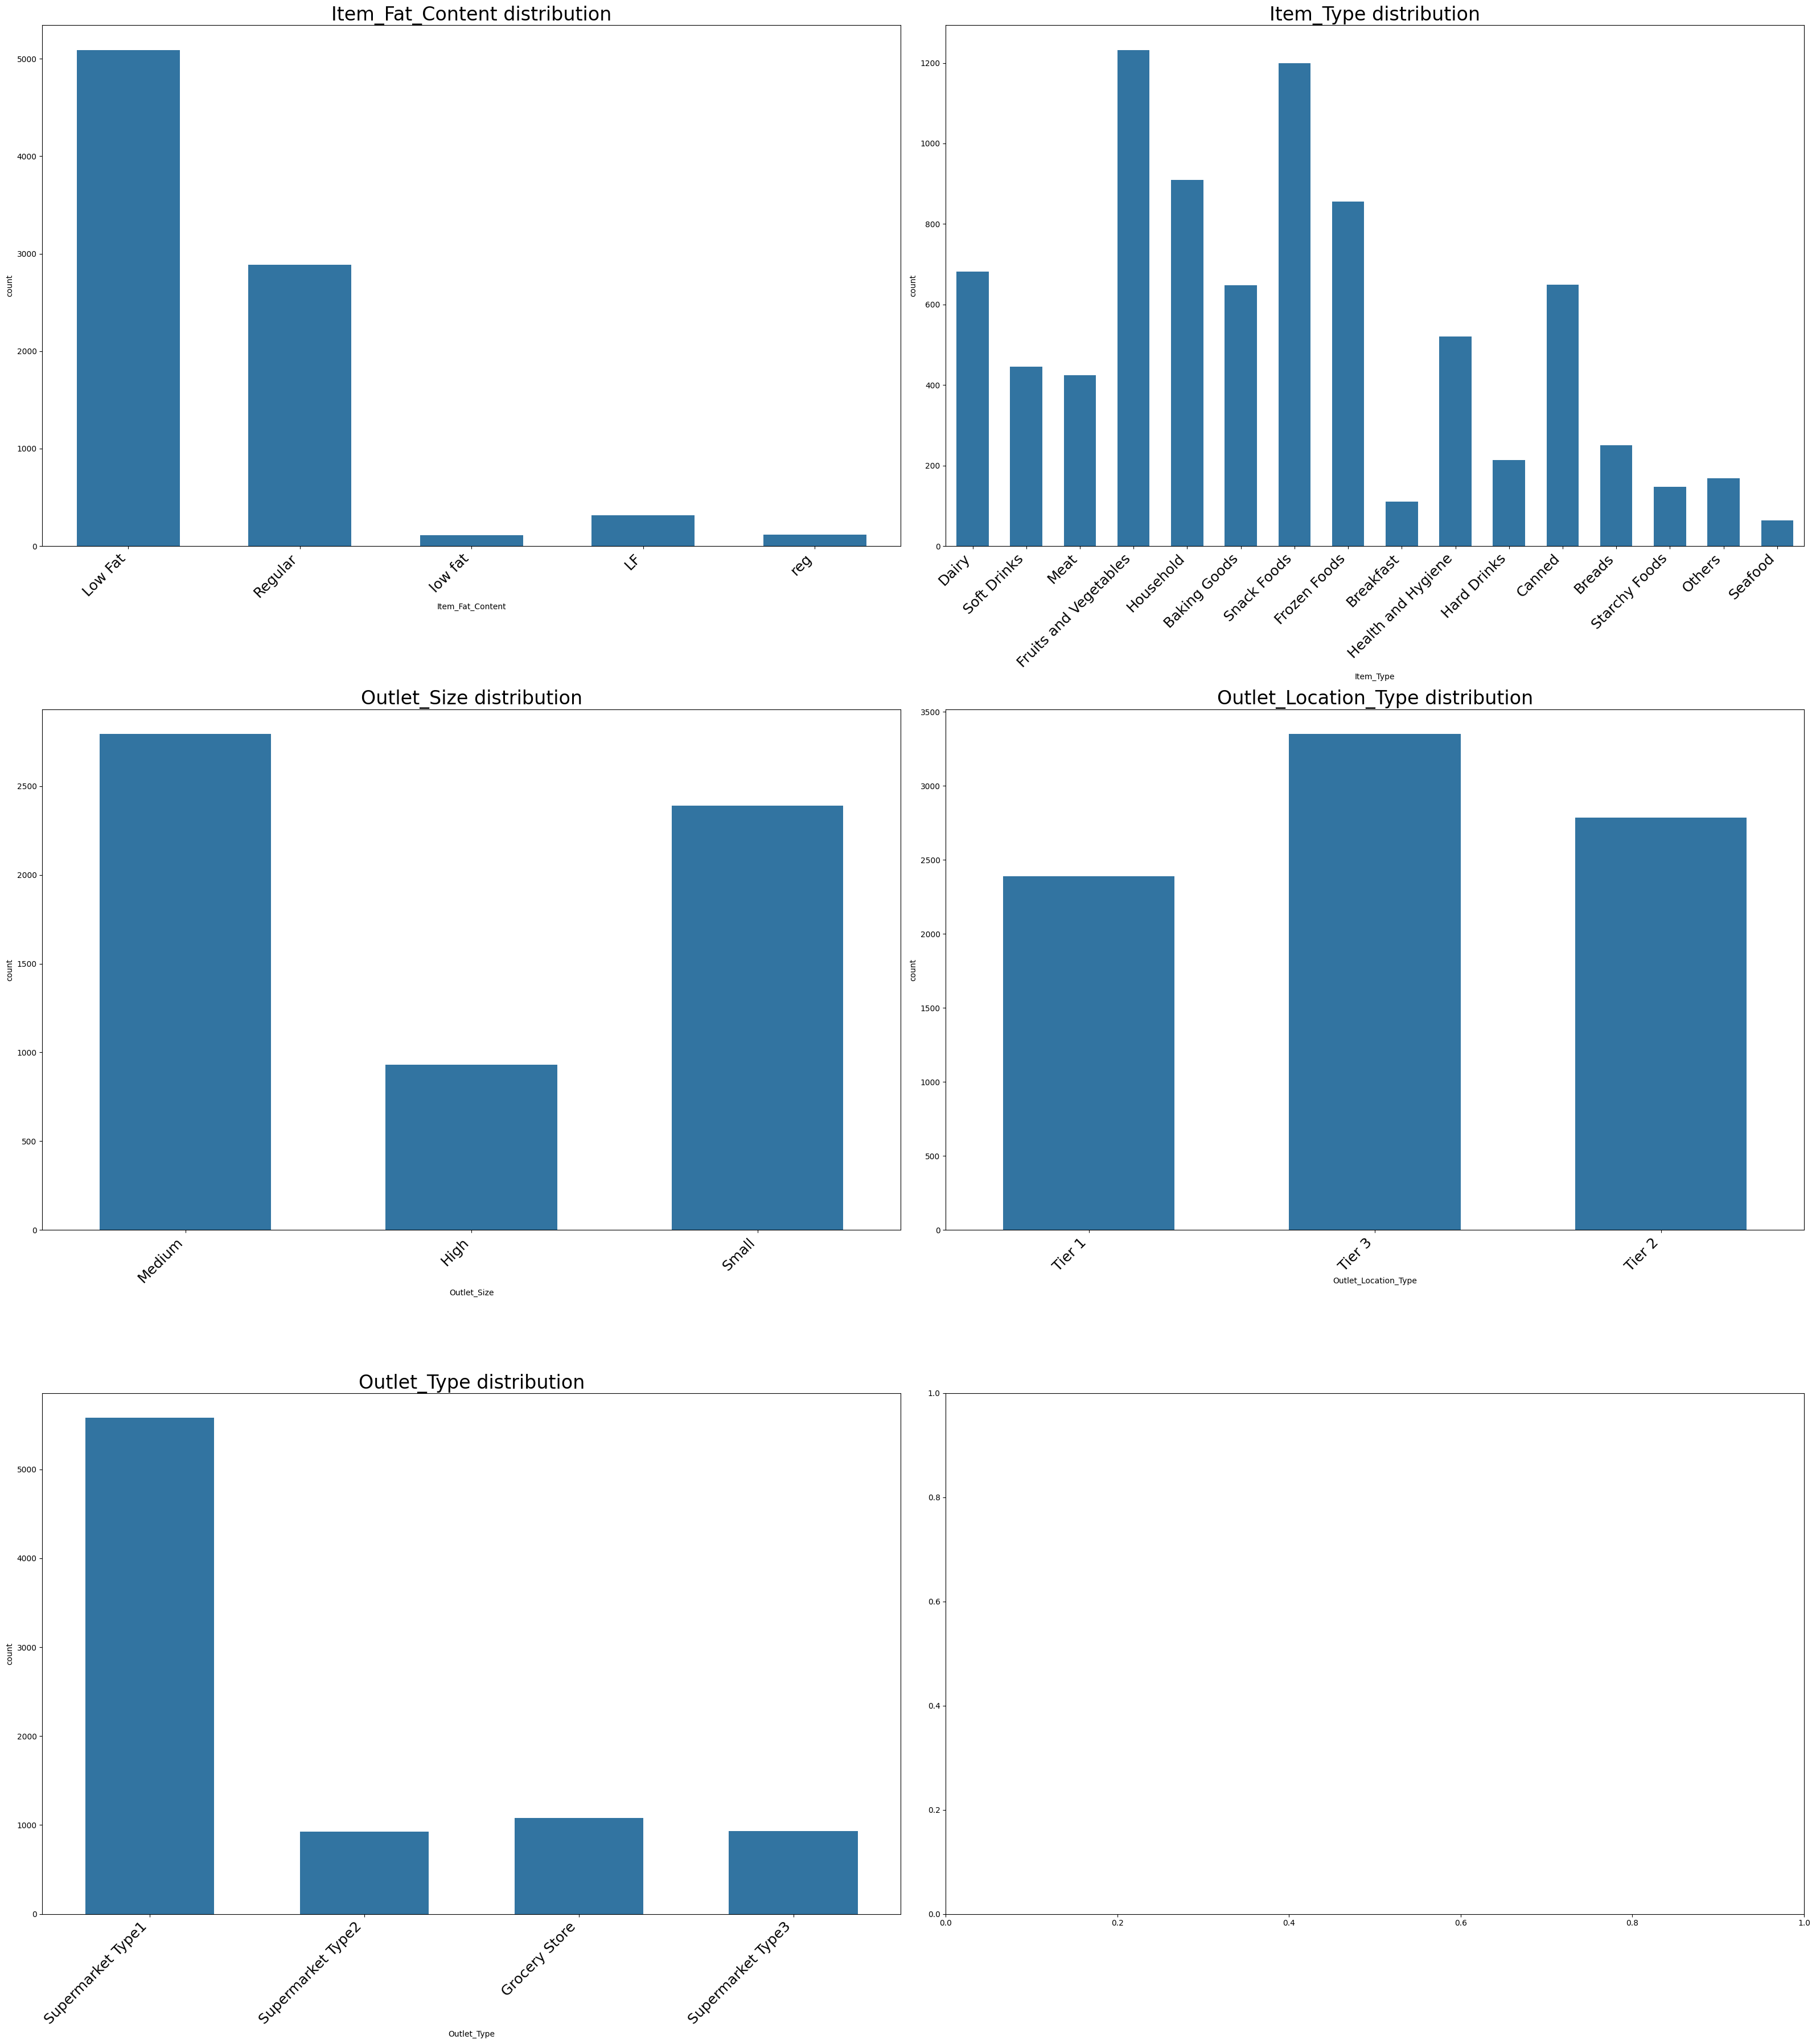

In [12]:
_, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (32,36))
for index, col in enumerate(categorical_to_display):
    r = index // 2
    c = index % 2
    g = sns.countplot(data = train, x = col, ax = ax[r][c], width = 0.6)
    g.set_xticklabels(g.get_xticklabels(), rotation = 45, ha = 'right', fontsize = 18)
    ax[r][c].set_title(f'{col} distribution', fontsize =24)
    plt.tight_layout()
''' Item_Fat_Content has some entry errors (Low Fat, LF, low fat should be considered as 1)
Same problem with variable Regular and reg
    Item_Type: should categorise the variables having same attribution (soft drink
and hard drink is about drink; seafood, snack foods, starchy foods, frozen foods as Food)
    Encode Outlet_Location_Type (from Tier 1 -> 1)'''

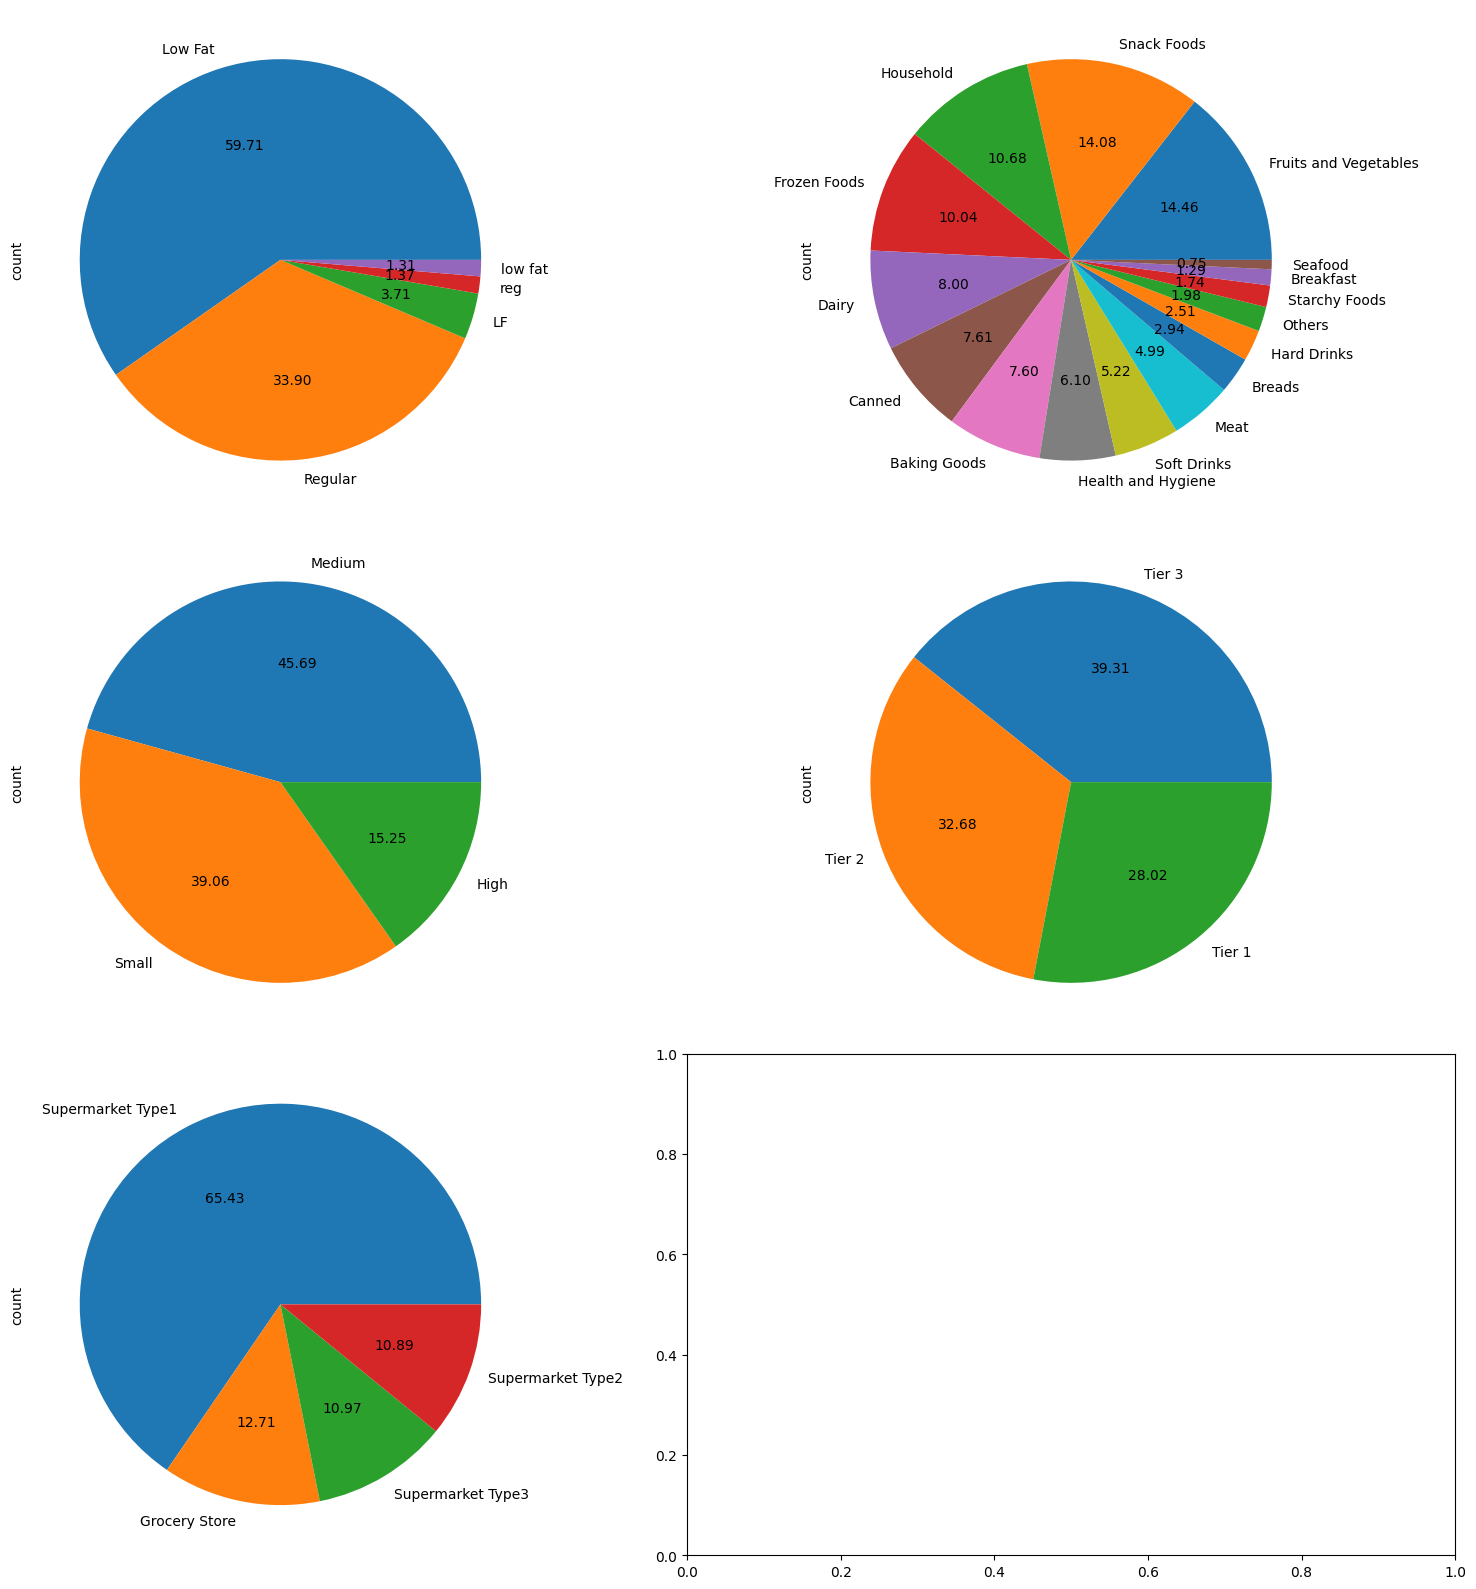

In [13]:
_, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (16,16))
for index, col in enumerate(categorical_to_display):
    r = index // 2
    c = index % 2
    train[col].value_counts().plot(kind = 'pie', autopct = '%.2f', ax = ax[r][c])
    plt.tight_layout()

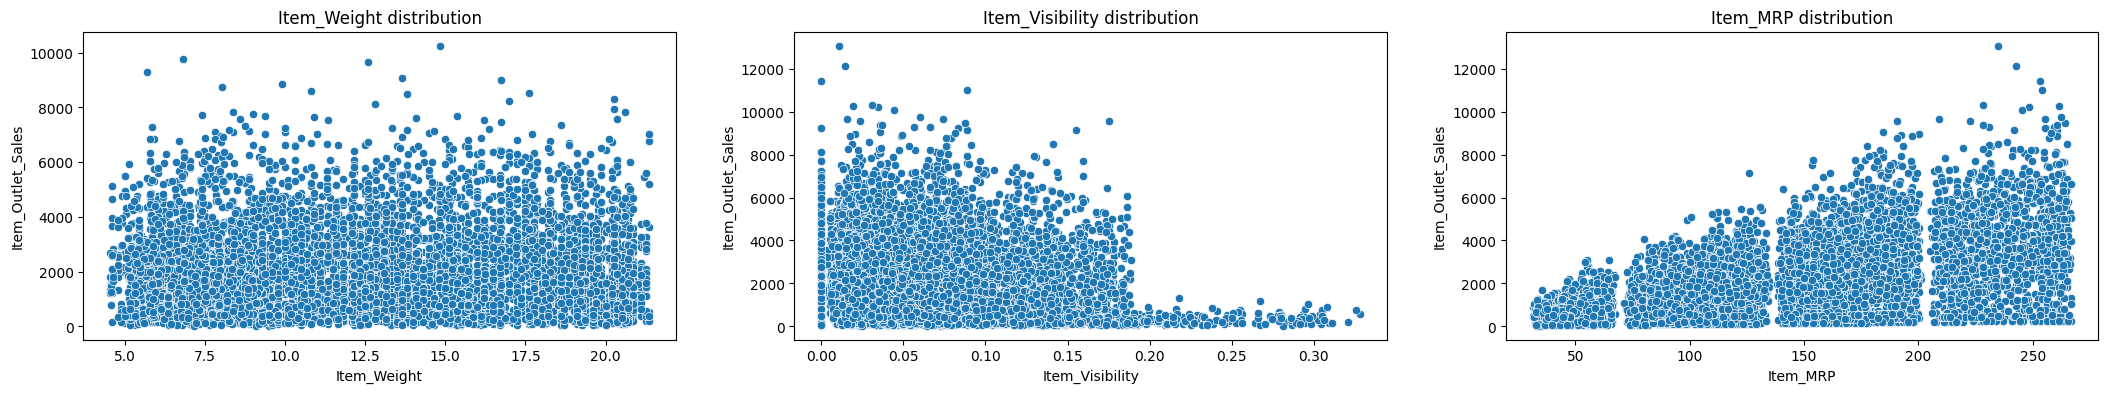

In [14]:
target = 'Item_Outlet_Sales'
_, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (26,4))
for index, col in enumerate(['Item_Weight','Item_Visibility','Item_MRP']):
    sns.scatterplot(data = train , x = col, y = target, ax = ax[index])
    ax[index].set_title(f'{col} distribution')
# Define outliers in these variables but dont know exactly where outliers lie in the data

'In Item_Weight, outliers are from Supermarket Type 1\n    In Item_Visibility and Item_MRP, outliers are from Supermarket Type 3'

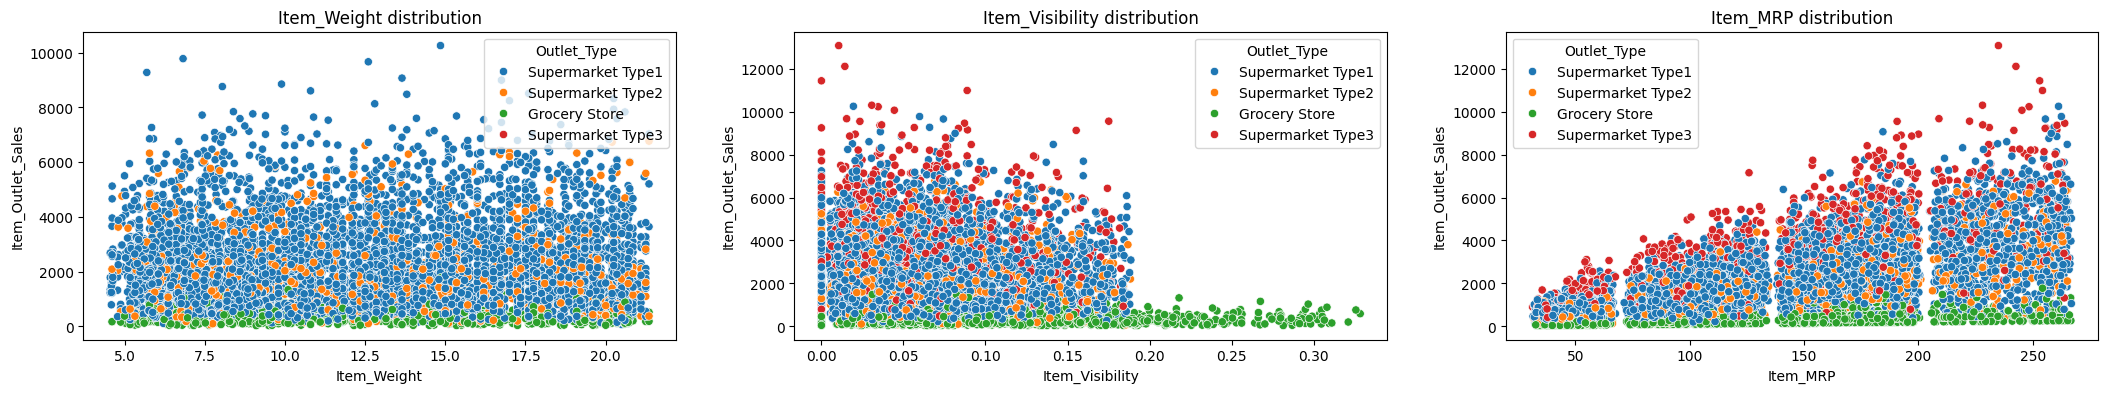

In [15]:
_, ax = plt.subplots(nrows = 1 , ncols = 3 , figsize = (26,4))
for index, col in enumerate(['Item_Weight','Item_Visibility','Item_MRP']):
    sns.scatterplot(data = train, x = col, y = target, ax = ax[index],hue = 'Outlet_Type')
    ax[index].set_title(f'{col} distribution')
# Define exactly outliers lie in the dataset based on Outlet_Type
'''In Item_Weight, outliers are from Supermarket Type 1
    In Item_Visibility and Item_MRP, outliers are from Supermarket Type 3'''

<Axes: >

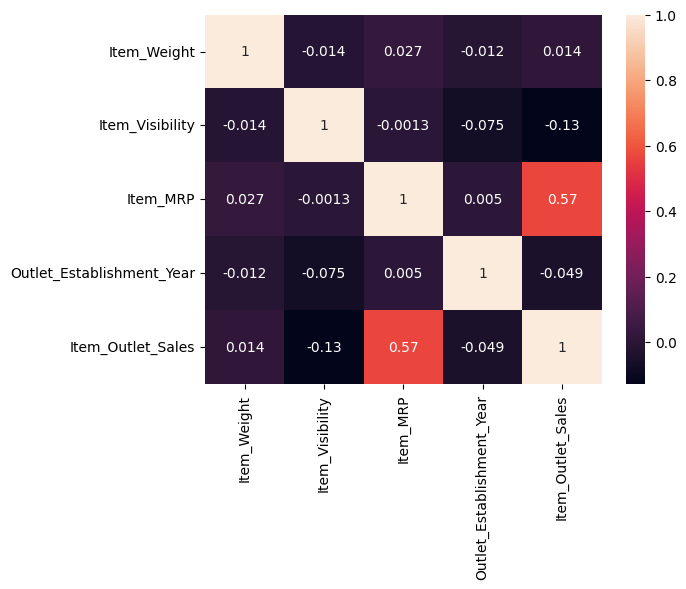

In [18]:
sns.heatmap(train.corr(numeric_only= True), annot=True)

<Axes: xlabel='Outlet_Size', ylabel='Item_Outlet_Sales'>

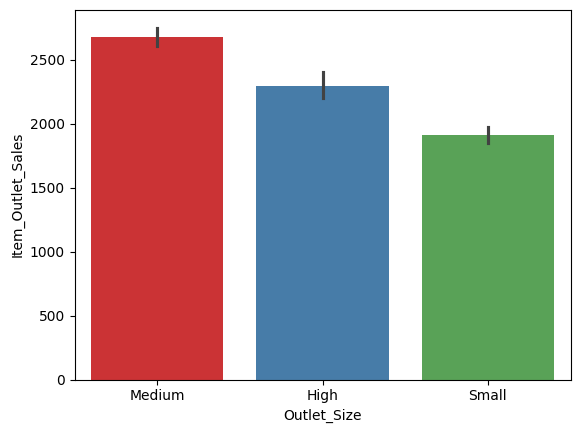

In [19]:
sns.barplot(data = train, x ='Outlet_Size', y = target, palette = 'Set1')

In [20]:
train['Outlet_Establishment_Year']
#filling the object values with mode and float values with mean
#   for train
train['Outlet_Size'] = train['Outlet_Size'].fillna(train['Outlet_Size'].dropna().mode()[0])
# train['Outlet_Size'].dropna().mode() returns a series
train['Item_Weight'] = train['Item_Weight'].fillna(train['Item_Weight'].mean())

#   for test
test['Outlet_Size'] = test['Outlet_Size'].fillna(test['Outlet_Size'].dropna().mode()[0])
test['Item_Weight'] = test['Item_Weight'].fillna(test['Item_Weight'].mean())

In [21]:
#function to detect outliers using the IQR method
def detect_outliers(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + (1.5 * IQR)
    lower_limit = Q1 - (1.5 * IQR)
    return upper_limit, lower_limit
upper, lower = detect_outliers(train, 'Item_Visibility')
print('Upper limit: ', upper)
print('Lower limit: ', lower)

Upper limit:  0.195979015
Lower limit:  -0.07440424500000001


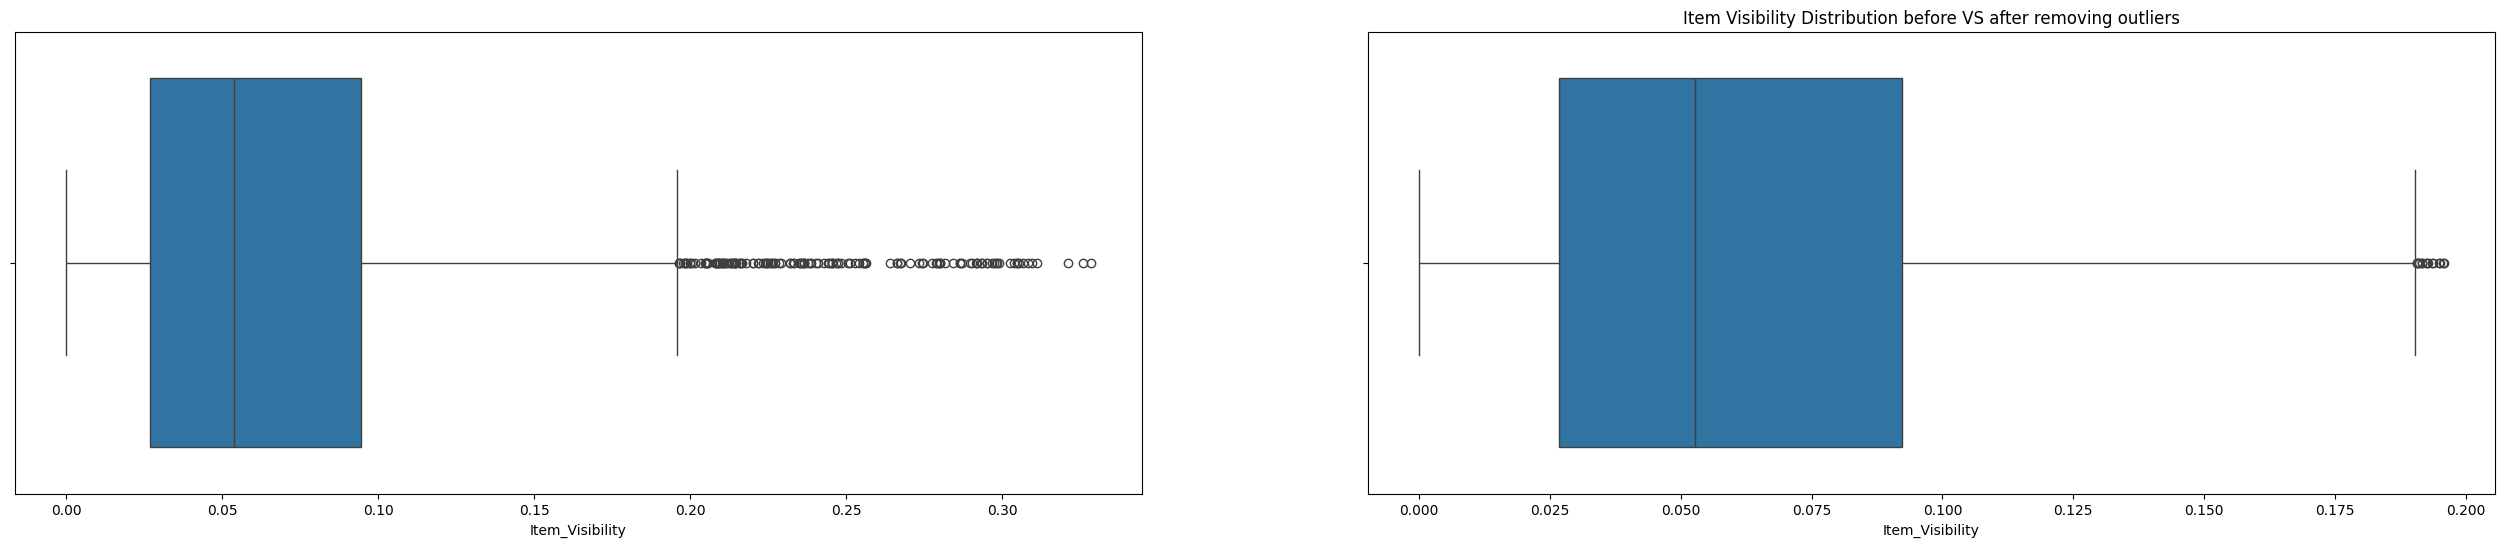

In [22]:
#Detect outliers in Item Visibility
_, ax = plt.subplots(nrows = 1 , ncols = 2, figsize = (32,6))
sns.boxplot(x = train['Item_Visibility'], ax = ax[0])
#removing outliers using the above results
train = train[(train['Item_Visibility'] > lower ) & (train['Item_Visibility'] < upper)]
test = test[(test['Item_Visibility' ] > lower ) & (test['Item_Visibility'] < upper)]
#Visualisation before vs after
sns.boxplot(x = train['Item_Visibility'], ax = ax[1])
plt.title('Item Visibility Distribution before VS after removing outliers')
plt.show(); 


Upper limit:  6499.2067
Lower limit:  -2499.7460999999994


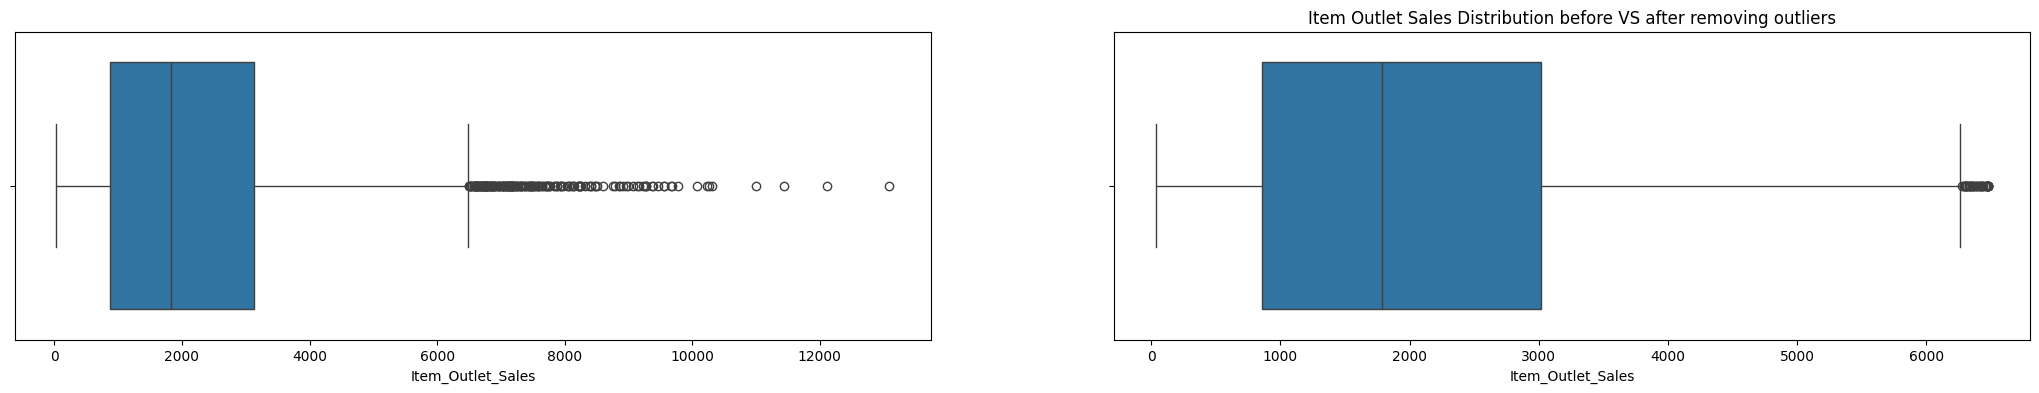

In [23]:
#Detect outliers in the Item_Outlet_Sales
upper, lower = detect_outliers(train, 'Item_Outlet_Sales')
print('Upper limit: ', upper)
print('Lower limit: ', lower)
#removing outliers using the above results
_, ax = plt.subplots(nrows = 1 , ncols = 2, figsize = (26,4))
sns.boxplot(x = train['Item_Outlet_Sales'], ax = ax[0])
train = train[(train['Item_Outlet_Sales'] > lower) & (train['Item_Outlet_Sales'] < upper)]
#Visualisation before vs after
sns.boxplot(x = train['Item_Outlet_Sales'], ax = ax[1])
plt.title('Item Outlet Sales Distribution before VS after removing outliers')
plt.show(); 

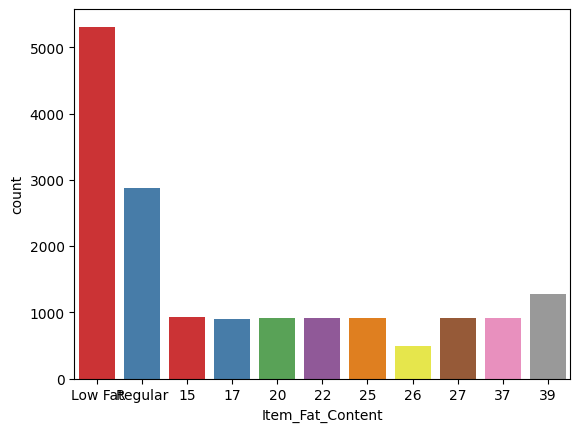

In [24]:
train['Item_Fat_Content'] = train['Item_Fat_Content'].map({'Low Fat': 'Low Fat', 
        'LF' : 'Low Fat', 'low fat': 'Low Fat', 'Regular': 'Regular', 'reg':'Regular'})
test['Item_Fat_Content'] = test['Item_Fat_Content'].map({'Low Fat': 'Low Fat', 
        'LF' : 'Low Fat', 'low fat': 'Low Fat', 'Regular': 'Regular', 'reg':'Regular'})
sns.countplot(x = train['Item_Fat_Content'], palette = 'Set1'); 
#getting the amount of established year in new column and delete the old column
train['Outlet_Age'] = 2024 - train['Outlet_Establishment_Year']
test['Outlet_Age'] = 2024 - test['Outlet_Establishment_Year']
del train['Outlet_Establishment_Year']
del test['Outlet_Establishment_Year']

sns.countplot(x = train['Outlet_Age'], palette = 'Set1'); 


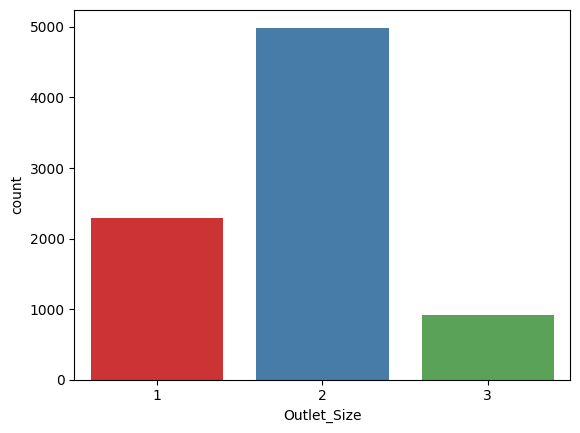

In [25]:
#Encoding Lable
train['Outlet_Size'] = train['Outlet_Size'].map(
    {'Small': 1, 'Medium': 2,'High': 3}).astype(int)
test['Outlet_Size'] = test['Outlet_Size'].map(
    {'Small': 1, 'Medium': 2,'High': 3}).astype(int)
sns.countplot(x = train['Outlet_Size'], palette = 'Set1'); 

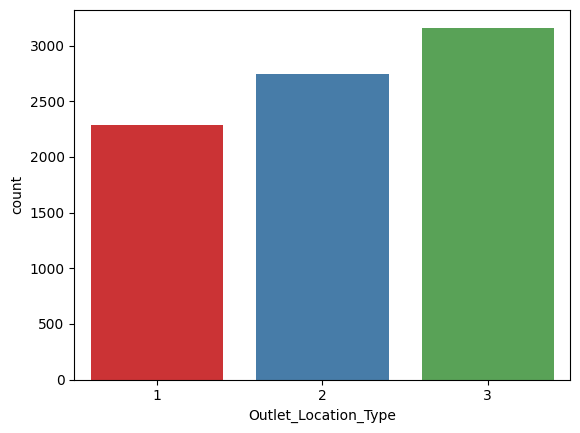

In [26]:
#Outlet_Location_Type feature encoding by getting the last character and convert it into integer
train['Outlet_Location_Type'] = train['Outlet_Location_Type'].str[-1:].astype(int)
test['Outlet_Location_Type'] = test['Outlet_Location_Type'].str[-1:].astype(int)
sns.countplot(x = train['Outlet_Location_Type'], palette = 'Set1'); 

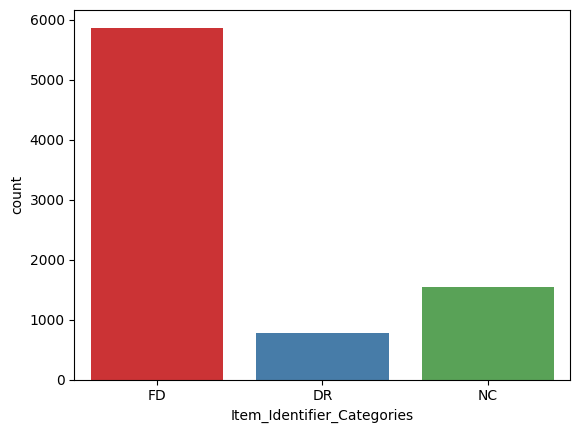

In [27]:
#Item Identifier feature encoding
train['Item_Identifier_Categories'] = train['Item_Identifier'].str[0:2]
test['Item_Identifier_Categories'] = test['Item_Identifier'].str[0:2]
sns.countplot(x = train['Item_Identifier_Categories'], palette = 'Set1'); 

In [28]:
encoder = LabelEncoder()
ordinal_features = ['Item_Fat_Content','Outlet_Type','Outlet_Location_Type']
for feature in ordinal_features:
    train[feature] = encoder.fit_transform(train[feature])
    test[feature] = encoder.fit_transform(test[feature])
train.shape
test.shape

(5570, 12)

In [29]:
#One Hot Coding
train = pd.get_dummies(train,columns = ['Item_Type','Item_Identifier_Categories','Outlet_Identifier'],drop_first=True)
test = pd.get_dummies(test,columns = ['Item_Type','Item_Identifier_Categories','Outlet_Identifier'],drop_first=True)

In [30]:
#Pre-Processing Data
train.drop(labels = ['Item_Identifier'], axis = 1 ,inplace = True)
test.drop(labels = ['Item_Identifier'], axis = 1 , inplace = True)
X = train.drop(labels = ['Item_Outlet_Sales'], axis = 1)
y = train['Item_Outlet_Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [33]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train,y_train)
lin_reg_predictions = lin_reg_model.predict(X_test)
print('Training Score: {}'.format(lin_reg_model.score(X_train, y_train)))
print('Test Score: {}'.format(lin_reg_model.score(X_test, y_test)))
'''~54-55% of the variability in Item Outlet Sales could be predicted by predictive model/independent variables.
The remaining of the variability could be explained by variables not in the model, random factors.
In other words, it indicates how well data fit with predictive models
'''

Training Score: 0.5516657749034781
Test Score: 0.5471728591811285


'~54-55% of the variability in Item Outlet Sales could be predicted by predictive model/independent variables.\nThe remaining of the variability could be explained by variables not in the model, random factors.\nIn other words, it indicates how well data fit with predictive models\n'

In [32]:
#Evaluation
lin_reg_mse = mean_squared_error(y_test, lin_reg_predictions)
lin_reg_rmse = math.sqrt(lin_reg_mse)
lin_reg_v2 = r2_score(y_test, lin_reg_predictions)
print('RMSE \t   ---->{}'.format(lin_reg_mse))
'''MSE: the degree of spread of the OBSERVED dependent variable in the model (similar with Variance)
    RMSE: the degree of accuracy/closeness of the PREDICTED values comparing with OBSERVED values (similar with STD)
'''
print('R2 score  ---->{}'.format(lin_reg_v2))


RMSE 	   ---->1043506.056642051
R2 score  ---->0.5471728591811285


In [34]:
steps = [
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2)),
    ('model',  LinearRegression())
       ]

lin_reg_pipeline = Pipeline(steps)

lin_reg_pipeline.fit(X_train, y_train)

print('Training score  : {}'.format(lin_reg_pipeline.score(X_train, y_train)))
print('Test score      : {}'.format(lin_reg_pipeline.score(X_test, y_test)))

Training score  : 0.5998188011416841
Test score      : 0.5664480054142293
